In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np

In [4]:
df = pd.read_csv('../../output/03_aspi_handled.csv')

In [ ]:
# 2. Extract Main and Sub sections
df['Main Section'] = df['sector'].str.strip()
df['Sub Section'] = 'General'

# 3. List the unique sections for your reference
print("--- Hierarchy List ---")
hierarchy = df.groupby(['Main Section', 'Sub Section']).size().reset_index(name='Count')
for main in hierarchy['Main Section'].unique():
    subs = hierarchy[hierarchy['Main Section'] == main]['Sub Section'].tolist()
    print(f"{main}: {', '.join(subs)}")

--- Hierarchy List ---
Automobiles: General
Banks: General
Capital Goods: General
Commercial Services: General
Consumer Durables: General
Consumer Services: General
Diversified Financials: General
Energy: General
Food & Beverage: General
Food Retailing: General
Healthcare Equipment: General
Household Products: General
Insurance: General
Materials: General
Others: General
Real Estate: General
Retailing: General
Software & Services: General
Telecommunication Services: General
Transportation: General
Utilities: General


In [9]:
%pip install nbformat --upgrade

Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/7 [fastjsonschema]
   ---------------------------------------- 0/7 [fastjsonschema]
   ----- ---------------------------------- 1/7 [rpds-py]
   ----------- ---------------------------- 2/7 [attrs]
   ----------- ---------------------------- 2/7 [attrs]
   ----------- ---------------------------- 2/7 [attrs]
   ----------- ---------------------------- 2/7 [attrs]
   ----------- ---------------------------- 2/7 [attrs]
   ----------------- ---------------------- 3/7 [referencing]
   ----------------- ---------------------- 3/7 [referencing]
   ----------------- ---------------------- 3/7 [referencing]
   ----------------- ---------------------- 3/7 [referencing]
   ---------------------- ----------------- 4/7 [jsonschema-specifications]
   ---------------------------- ----------- 5/7 [jsonschema]
   ---------------------------- ----------- 5/7 [jsonschema]
   ----

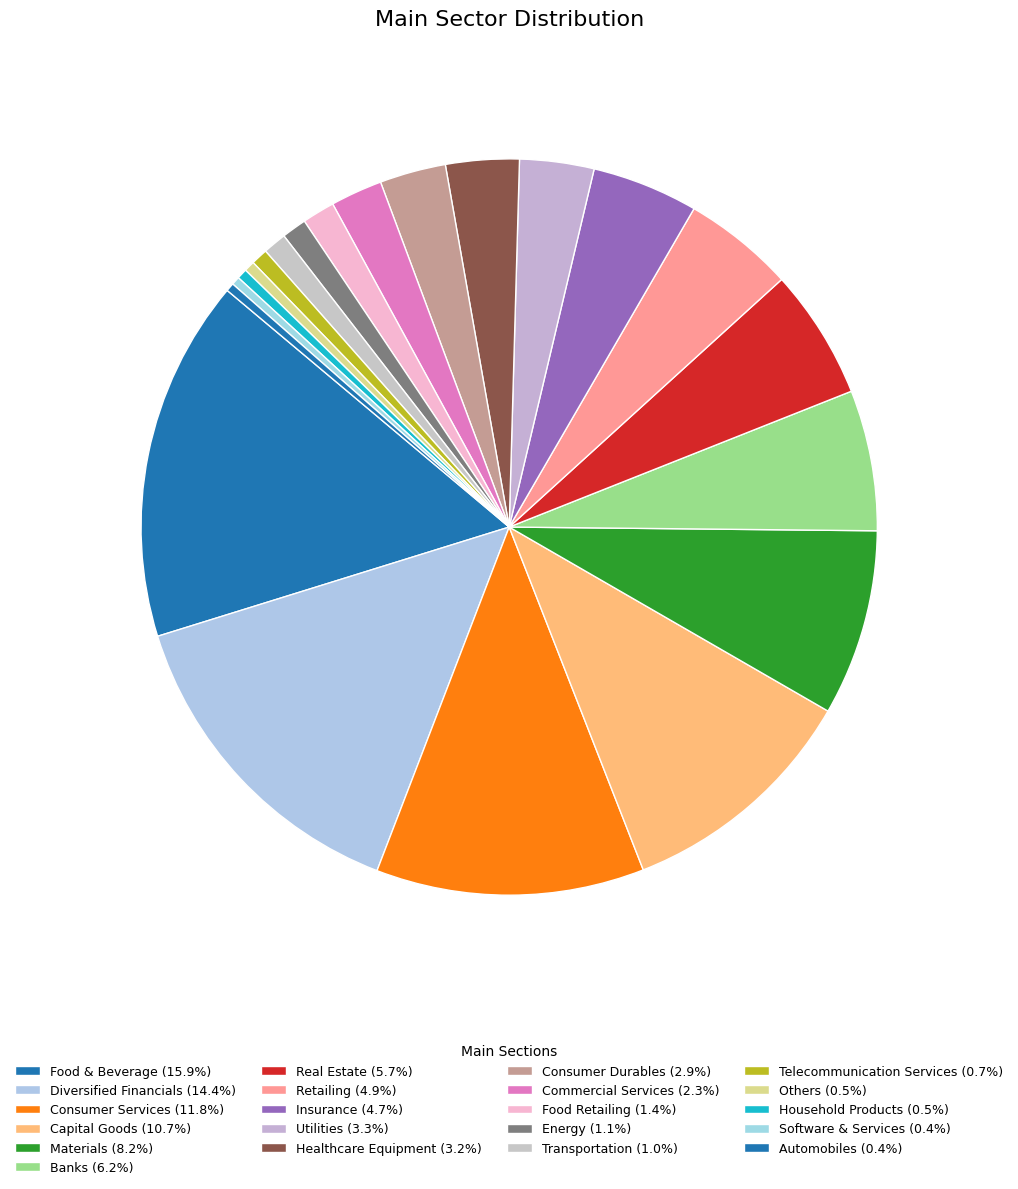

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate counts and percentages
main_counts = df['Main Section'].value_counts()
total = main_counts.sum()

# 2. Setup the Plot
plt.figure(figsize=(12, 12))
colors = sns.color_palette("tab20", n_colors=20)

# 3. Create the Pie
# autopct uses a lambda: if the value is < 2%, it returns an empty string
wedges, texts, autotexts = plt.pie(
    main_counts, 
    autopct= '', 
    startangle=140, 
    colors=colors,
    pctdistance=0.82,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)

# Style the visible percentages
plt.setp(autotexts, size=9, weight="bold", color="white")

# 4. Create Custom Legend Labels (Sector Name + Percentage)
legend_labels = [f'{label} ({ (count/total)*100:.1f}%)' 
                 for label, count in zip(main_counts.index, main_counts)]

# 5. Position Legend at the bottom in 4 columns
plt.legend(
    wedges, legend_labels,
    title="Main Sections",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=4, 
    fontsize=9,
    frameon=False
)

plt.title('Main Sector Distribution', fontsize=16, pad=30)
plt.tight_layout()
plt.show()

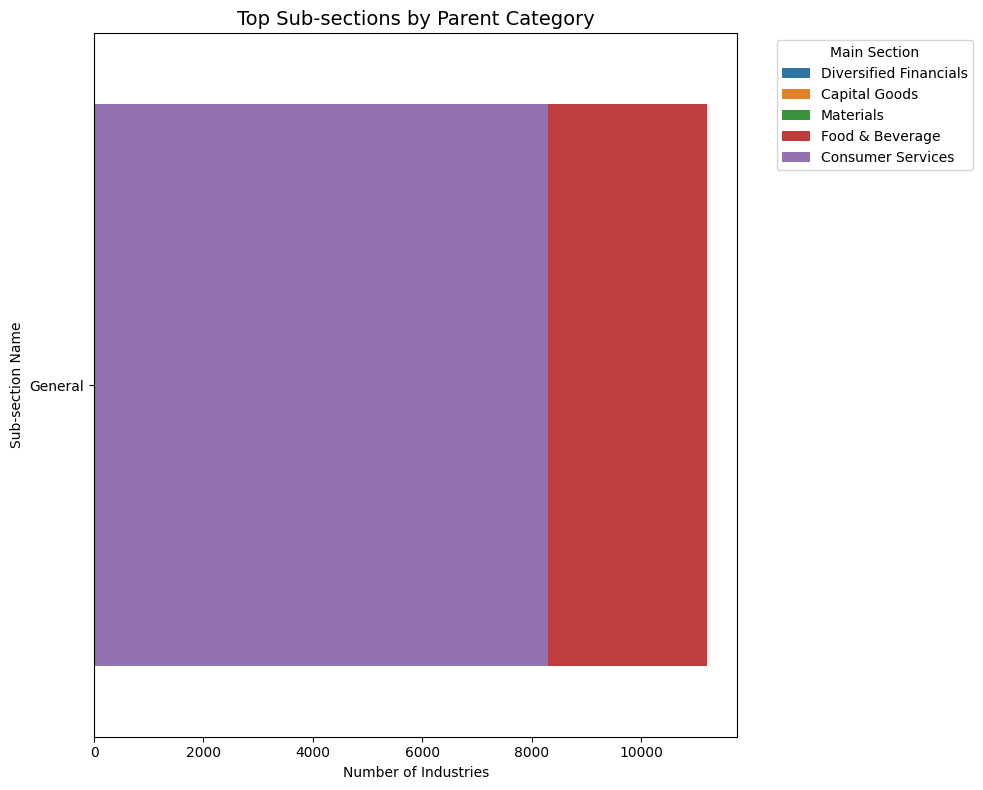

In [7]:
# 2. Filter to only show sub-sections for the top N main categories
top_n_mains = df['Main Section'].value_counts().nlargest(5).index
filtered_subs = df[df['Main Section'].isin(top_n_mains)]

# Aggregate and plot
plt.figure(figsize=(10, 8))
sns.countplot(
    data=filtered_subs, 
    y='Sub Section', 
    hue='Main Section', 
    order=filtered_subs['Sub Section'].value_counts().index,
    dodge=False # Stacked look or side-by-side
)

plt.title('Top Sub-sections by Parent Category', fontsize=14)
plt.xlabel('Number of Industries')
plt.ylabel('Sub-section Name')
plt.legend(title='Main Section', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [8]:
# Convert date and ensure no NaNs
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date', 'alpha', 'beta', 'R_i', 'R_m'])

# alpha / beta distribution
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['alpha'], bins=40, kde=True, color='tab:blue')
plt.title('Alpha Distribution')
plt.xlabel('alpha')
plt.ylabel('count')

plt.subplot(1, 2, 2)
sns.histplot(df['beta'], bins=40, kde=True, color='tab:orange')
plt.title('Beta Distribution')
plt.xlabel('beta')
plt.ylabel('count')

plt.tight_layout()
plt.show()

KeyError: ['alpha', 'beta', 'R_i', 'R_m']

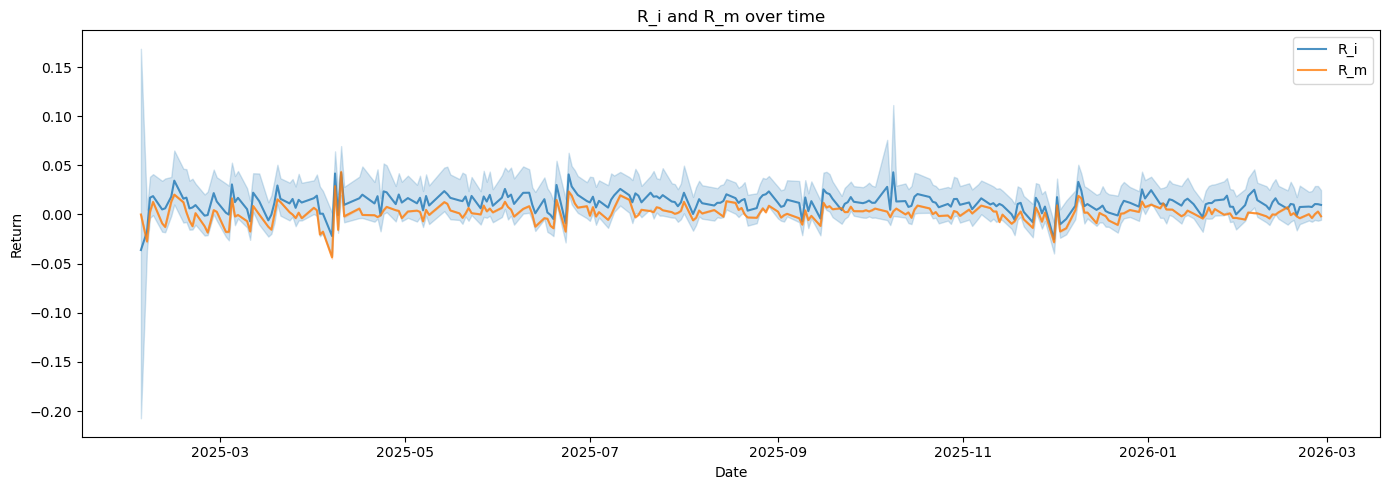

In [ ]:
# Time series of the two return series
plt.figure(figsize=(14, 5))
sns.lineplot(data=df.sort_values('date'), x='date', y='R_i', label='R_i', alpha=0.8)
sns.lineplot(data=df.sort_values('date'), x='date', y='R_m', label='R_m', alpha=0.8)
plt.title('R_i and R_m over time')
plt.xlabel('Date')
plt.ylabel('Return')
plt.legend()
plt.tight_layout()
plt.show()

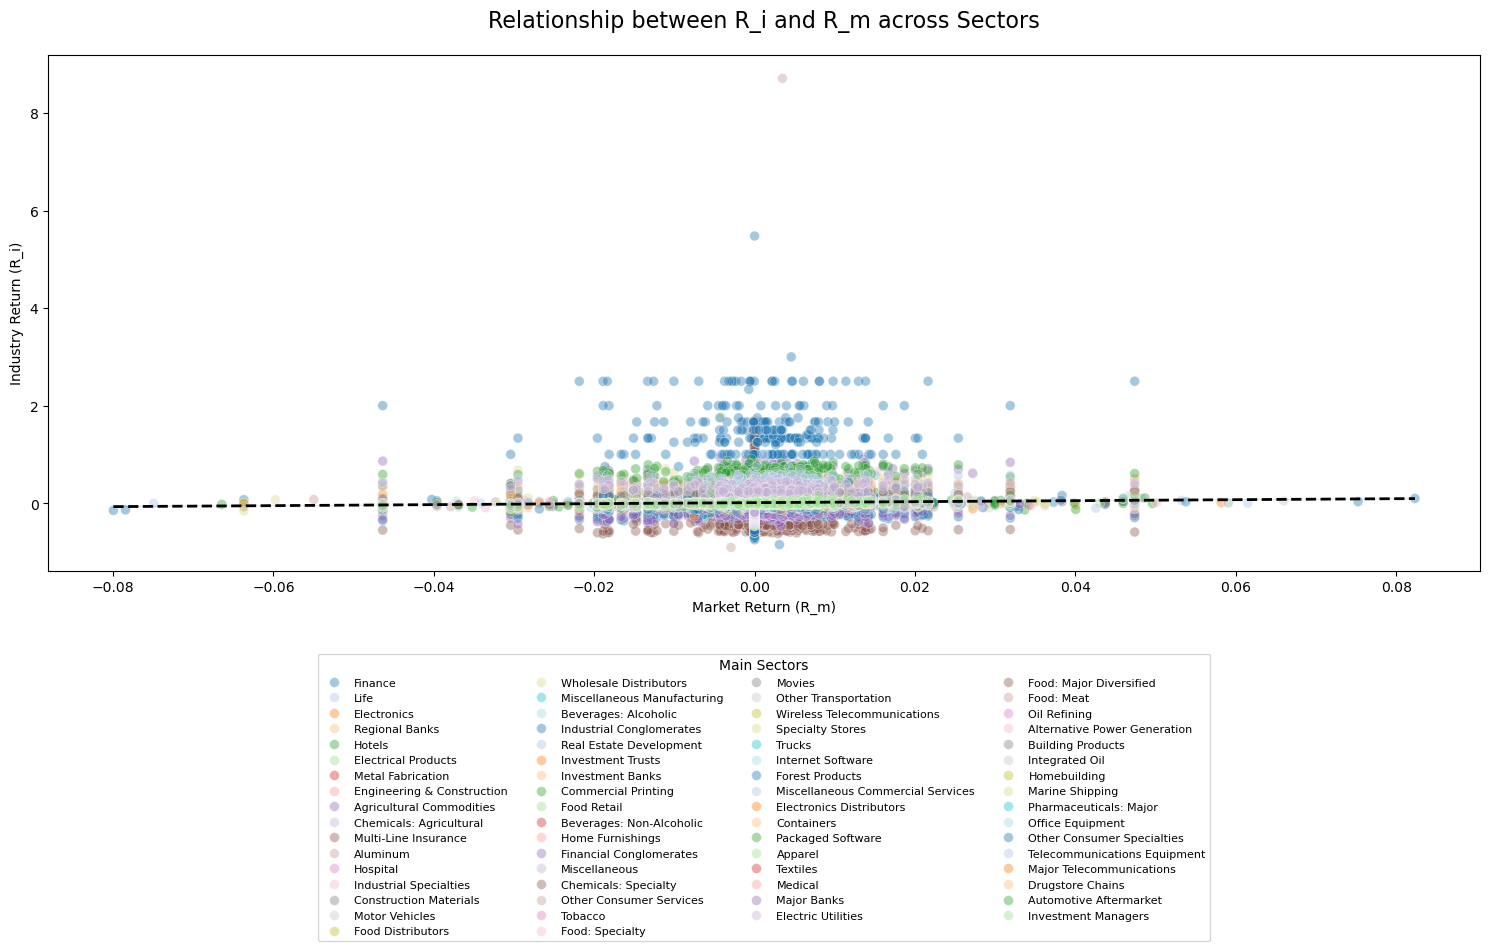

In [ ]:

# 1. Increase the height of the figure to accommodate the data better
plt.figure(figsize=(15, 10)) 

# 2. Plot with a smaller alpha and better markers
sns.scatterplot(
    data=df, x='R_m', y='R_i', 
    hue='Main Section', 
    alpha=0.4, s=50, palette='tab20',
    edgecolor='w', linewidth=0.5
)

# 3. Add the trend line
sns.regplot(
    data=df, x='R_m', y='R_i', 
    scatter=False, color='black', 
    line_kws={'linewidth': 2, 'linestyle': '--'}
)

# 4. CRITICAL: Handle the legend so it doesn't stretch the figure
# We use 'ncol=3' to spread names out horizontally and move it below the chart
plt.legend(
    title='Main Sectors', 
    bbox_to_anchor=(0.5, -0.15), # Moves it below the plot
    loc='upper center', 
    ncol=4,                      # Spread across 4 columns to save vertical space
    fontsize=8,
    frameon=True
)

plt.title('Relationship between R_i and R_m across Sectors', fontsize=16, pad=20)
plt.xlabel('Market Return (R_m)')
plt.ylabel('Industry Return (R_i)')

# 5. Remove excess white space
plt.tight_layout()
plt.show()

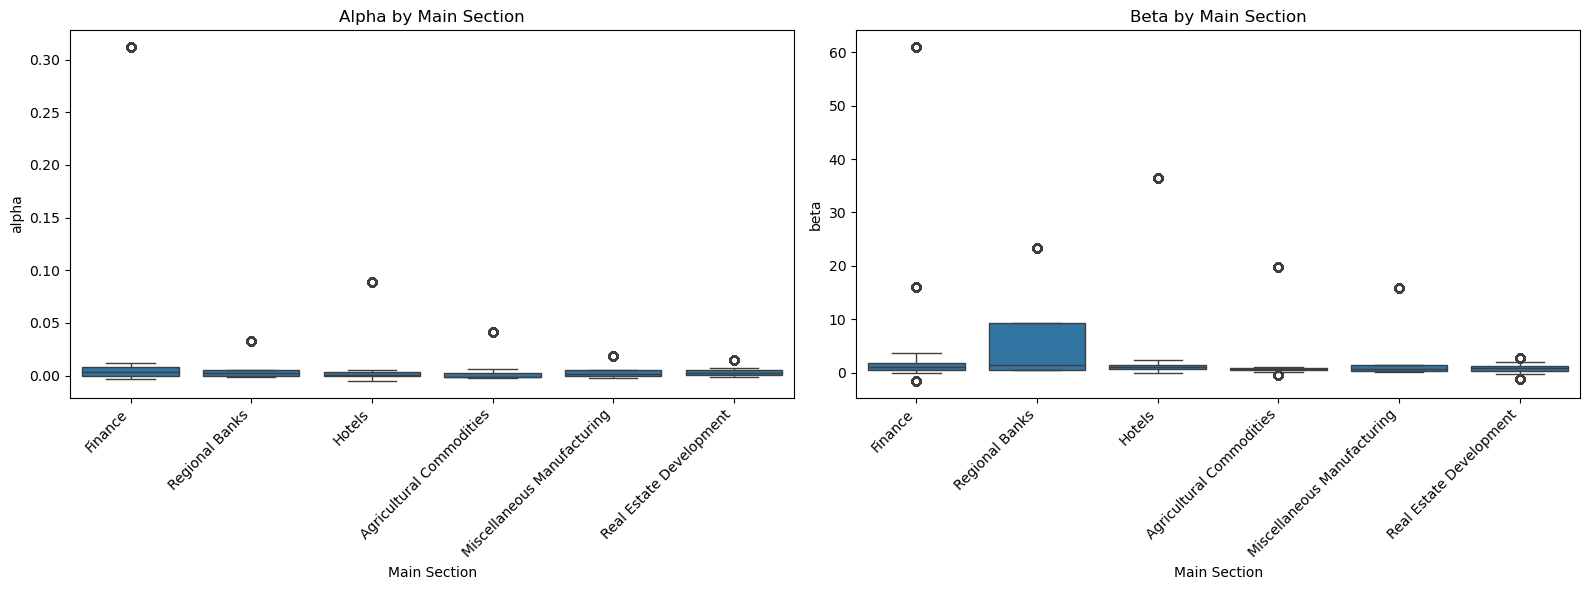

/var/folders/db/4m8dhthn51d8sxyp9mp9sd_00000gn/T/ipykernel_2618/1299843892.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top_sub.groupby('Sub Section').agg(mean_alpha=('alpha', 'mean')).reset_index(),


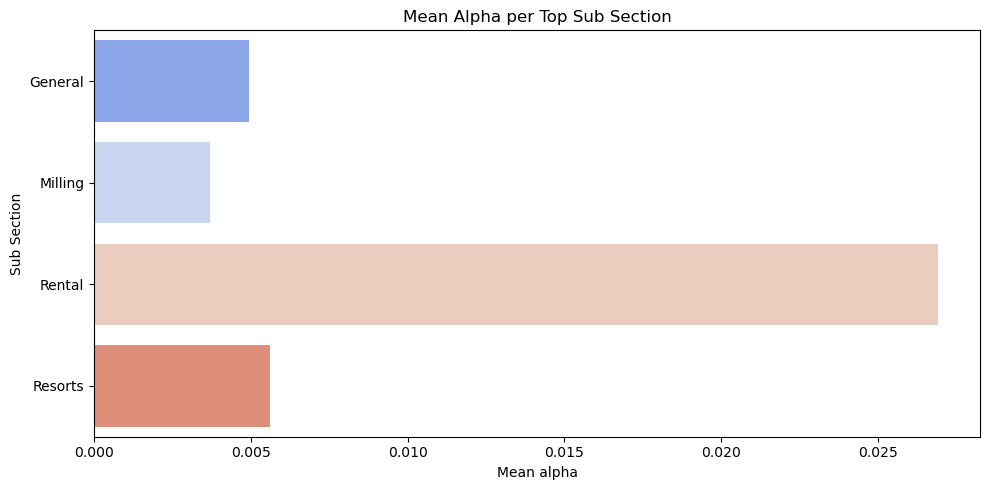

In [ ]:
top_main = df['Main Section'].value_counts().nlargest(6).index
df_top_main = df[df['Main Section'].isin(top_main)]

plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.boxplot(data=df_top_main, x='Main Section', y='alpha')
plt.xticks(rotation=45, ha='right')
plt.title('Alpha by Main Section')
plt.xlabel('Main Section')
plt.ylabel('alpha')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_top_main, x='Main Section', y='beta')
plt.xticks(rotation=45, ha='right')
plt.title('Beta by Main Section')
plt.xlabel('Main Section')
plt.ylabel('beta')

plt.tight_layout()
plt.show()

# top sub-sections inside top main sections
top_sub = df_top_main['Sub Section'].value_counts().nlargest(10).index
df_top_sub = df_top_main[df_top_main['Sub Section'].isin(top_sub)]

plt.figure(figsize=(10, 5))
sns.barplot(data=df_top_sub.groupby('Sub Section').agg(mean_alpha=('alpha', 'mean')).reset_index(),
            x='mean_alpha', y='Sub Section', palette='coolwarm')
plt.title('Mean Alpha per Top Sub Section')
plt.xlabel('Mean alpha')
plt.ylabel('Sub Section')
plt.tight_layout()
plt.show()

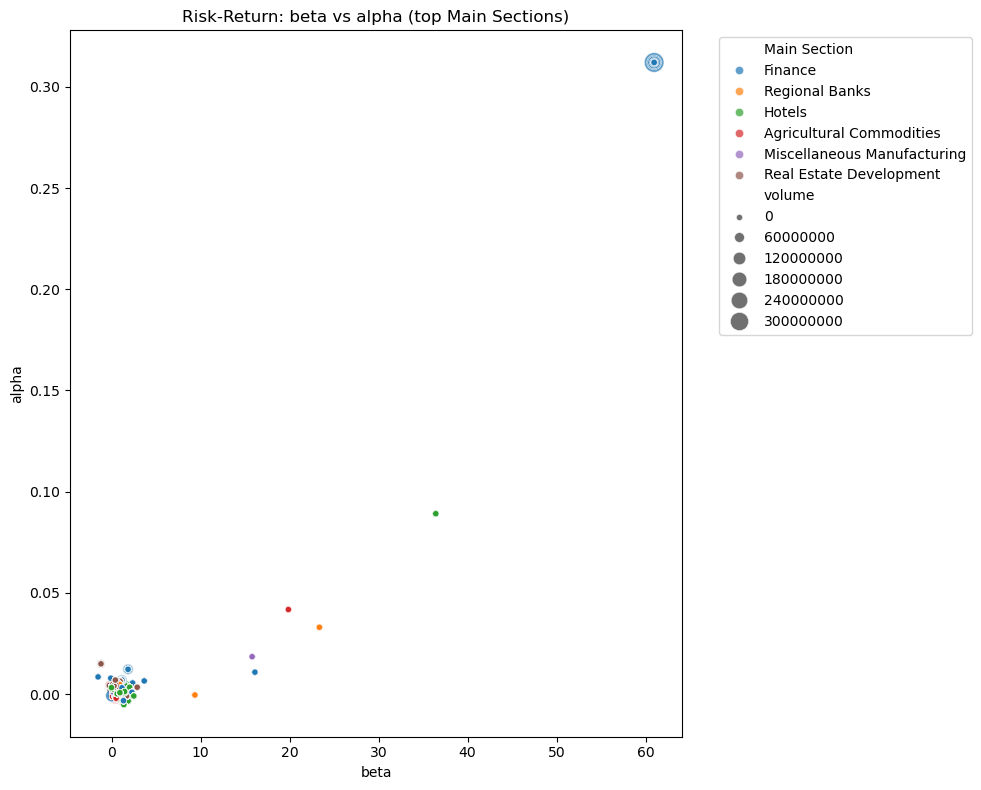

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_top_main,
    x='beta',
    y='alpha',
    hue='Main Section',
    size='volume' if 'volume' in df.columns else None,
    sizes=(20, 200),
    alpha=0.7,
    palette='tab10',
    edgecolor='w', linewidth=0.5
)
plt.title('Risk-Return: beta vs alpha (top Main Sections)')
plt.xlabel('beta')
plt.ylabel('alpha')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
